In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")

In [5]:
# Load datasets
sentiment = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv("historical_data.csv")

# Display first rows
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [21]:
print("Sentiment Dataset Shape:", sentiment.shape)
print("Trader Dataset Shape:", trader.shape)

sentiment.info()
trader.info()

Sentiment Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  flo

In [23]:
print("Missing values in Sentiment:\n", sentiment.isnull().sum())
print("\nMissing values in Trader:\n", trader.isnull().sum())

print("\nDuplicate rows in Sentiment:", sentiment.duplicated().sum())
print("Duplicate rows in Trader:", trader.duplicated().sum())

Missing values in Sentiment:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in Trader:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate rows in Sentiment: 0
Duplicate rows in Trader: 0


In [25]:
print(trader.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [27]:
# Convert all column names to lowercase and remove spaces
trader.columns = trader.columns.str.lower().str.strip()
sentiment.columns = sentiment.columns.str.lower().str.strip()

print(trader.columns)

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='object')


In [29]:
trader.rename(columns={
    'execution price': 'execution_price',
    'size tokens': 'size_tokens',
    'size usd': 'size_usd',
    'start position': 'start_position',
    'closed pnl': 'closed_pnl',
    'transaction hash': 'transaction_hash',
    'order id': 'order_id',
    'trade id': 'trade_id',
    'timestamp ist': 'timestamp_ist'
}, inplace=True)

print(trader.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')


In [33]:
trader['timestamp_ist'] = pd.to_datetime(trader['timestamp_ist'], dayfirst=True)

In [35]:
trader['date'] = trader['timestamp_ist'].dt.date

In [37]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [39]:
sentiment['date'] = pd.to_datetime(sentiment['date'], dayfirst=True)
sentiment['date'] = sentiment['date'].dt.date

In [41]:
merged = pd.merge(trader, sentiment, on='date', how='inner')

merged.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp_x,date,timestamp_y,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed


In [43]:
merged['win'] = np.where(merged['closed_pnl'] > 0, 1, 0)

In [45]:
merged['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [47]:
performance = merged.groupby('classification')['closed_pnl'].mean().reset_index()

performance

,classification,closed_pnl
0,Extreme Fear,34.537862
1,Extreme Greed,67.892861
2,Fear,54.290400
3,Greed,42.743559
4,Neutral,34.307718


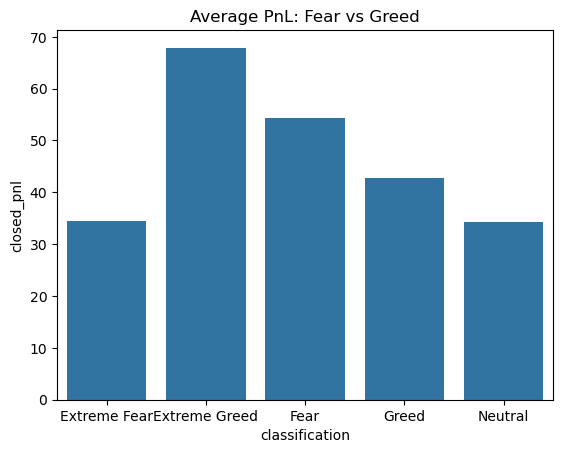

In [49]:
plt.figure()
sns.barplot(x='classification', y='closed_pnl', data=performance)
plt.title("Average PnL: Fear vs Greed")
plt.show()

In [51]:
win_rate_sentiment = merged.groupby('classification')['win'].mean().reset_index()

win_rate_sentiment

,classification,win
0,Extreme Fear,0.370607
1,Extreme Greed,0.464943
2,Fear,0.420768
3,Greed,0.384828
4,Neutral,0.396991


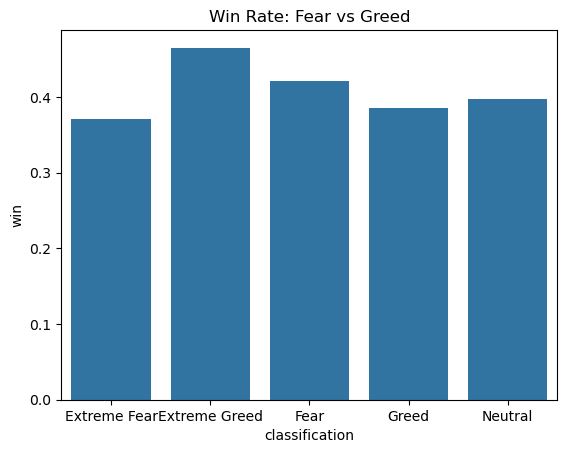

In [53]:
plt.figure()
sns.barplot(x='classification', y='win', data=win_rate_sentiment)
plt.title("Win Rate: Fear vs Greed")
plt.show()

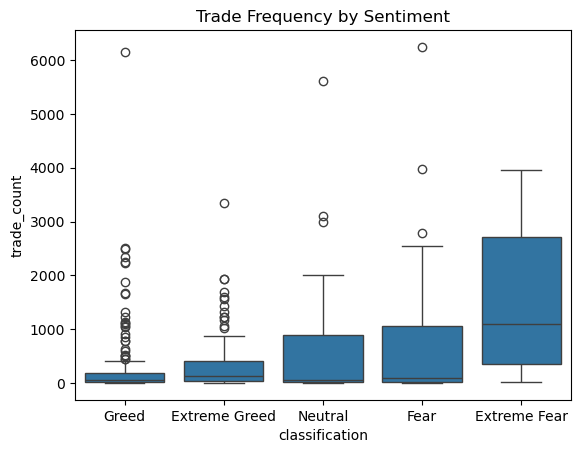

In [55]:
trades_per_day = merged.groupby(['date', 'classification']).size().reset_index(name='trade_count')

plt.figure()
sns.boxplot(x='classification', y='trade_count', data=trades_per_day)
plt.title("Trade Frequency by Sentiment")
plt.show()

In [57]:
size_behavior = merged.groupby('classification')['size_usd'].mean().reset_index()
size_behavior

,classification,size_usd
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


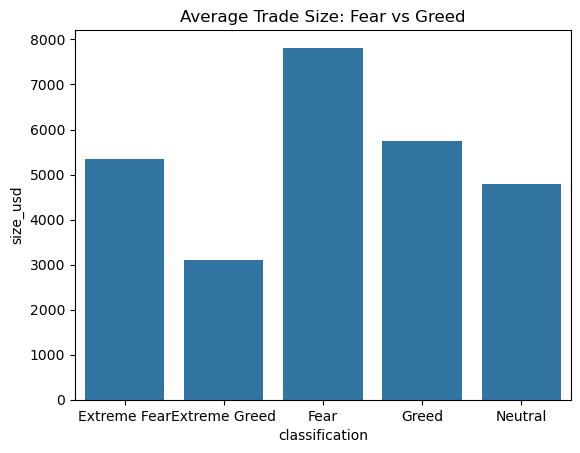

In [59]:
plt.figure()
sns.barplot(x='classification', y='size_usd', data=size_behavior)
plt.title("Average Trade Size: Fear vs Greed")
plt.show()

In [61]:
side_distribution = merged.groupby(['classification','side']).size().reset_index(name='count')

side_distribution

,classification,side,count
0,Extreme Fear,BUY,10935
1,Extreme Fear,SELL,10465
2,Extreme Greed,BUY,17940
3,Extreme Greed,SELL,22052
4,Fear,BUY,30270
5,Fear,SELL,31567
6,Greed,BUY,24576
7,Greed,SELL,25727
8,Neutral,BUY,18969
9,Neutral,SELL,18717


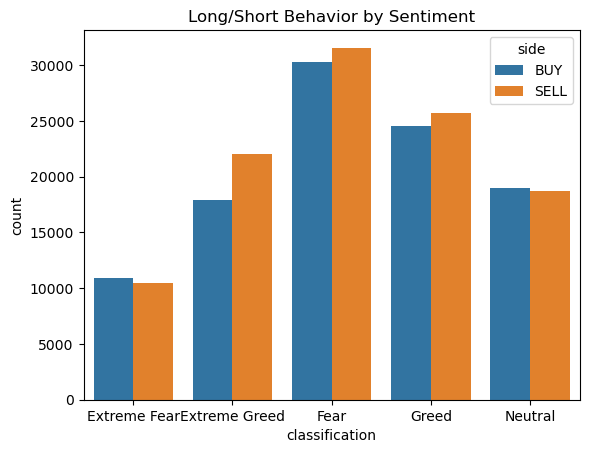

In [63]:
plt.figure()
sns.barplot(x='classification', y='count', hue='side', data=side_distribution)
plt.title("Long/Short Behavior by Sentiment")
plt.show()

In [65]:
median_size = merged['size_usd'].median()

merged['size_segment'] = np.where(
    merged['size_usd'] > median_size,
    'High Size',
    'Low Size'
)

In [67]:
segment_perf = merged.groupby(['classification','size_segment'])['closed_pnl'].mean().reset_index()

segment_perf

,classification,size_segment,closed_pnl
0,Extreme Fear,High Size,61.196379
1,Extreme Fear,Low Size,1.157202
2,Extreme Greed,High Size,140.570044
3,Extreme Greed,Low Size,9.628661
4,Fear,High Size,97.025581
5,Fear,Low Size,3.580906
6,Greed,High Size,84.301244
7,Greed,Low Size,3.609685
8,Neutral,High Size,69.581271
9,Neutral,Low Size,2.188668


In [69]:
trade_counts = merged['account'].value_counts()
median_trades = trade_counts.median()

frequent_accounts = trade_counts[trade_counts > median_trades].index

merged['frequency_segment'] = np.where(
    merged['account'].isin(frequent_accounts),
    'Frequent',
    'Infrequent'
)

In [73]:
freq_perf = merged.groupby(['classification','frequency_segment'])['closed_pnl'].mean().reset_index()
freq_perf

,classification,frequency_segment,closed_pnl
0,Extreme Fear,Frequent,34.163353
1,Extreme Fear,Infrequent,35.941979
2,Extreme Greed,Frequent,62.870911
3,Extreme Greed,Infrequent,103.264685
4,Fear,Frequent,51.323784
5,Fear,Infrequent,80.835791
6,Greed,Frequent,25.004641
7,Greed,Infrequent,210.210287
8,Neutral,Frequent,34.579701
9,Neutral,Infrequent,31.845656


In [75]:
merged.groupby(['classification','frequency_segment'])['closed_pnl'].agg(['count','mean'])

count        mean
classification frequency_segment                   
Extreme Fear   Frequent           16894   34.163353
               Infrequent          4506   35.941979
Extreme Greed  Frequent           35020   62.870911
               Infrequent          4972  103.264685
Fear           Frequent           55621   51.323784
               Infrequent          6216   80.835791
Greed          Frequent           45485   25.004641
               Infrequent          4818  210.210287
Neutral        Frequent           33937   34.579701
               Infrequent          3749   31.845656

Insight 1 — Infrequent Traders Consistently Outperform Frequent Traders

Across all sentiment regimes except Neutral, infrequent traders generate higher average PnL than frequent traders.

Insight 2 — Greed Markets Amplify Performance Dispersion

During Greed:

Frequent traders earn only 25 average PnL

Infrequent traders earn 210 average PnL

This is the largest performance gap observed.

This suggests that bullish sentiment environments reward selective high-conviction trades rather than frequent activity.

Frequent traders may suffer from overconfidence bias and excessive trading during Greed regimes.

Insight 3 — Fear Markets Show More Balanced Performance

During Extreme Fear:

Frequent → 34

Infrequent → 35

Performance gap narrows significantly.

This suggests that high uncertainty environments reduce behavioral differences between trader segments.

Fear regimes may encourage more disciplined and risk-controlled trading across participants.

Insight 4 — Neutral Regimes Show Minimal Advantage

During Neutral sentiment, performance between segments is very similar (34 vs 31).

This indicates that sentiment extremes, not normal markets, drive behavioral profitability differences.

Strategy Recommendations

1.Observation from Data:

During Greed, frequent traders earn only ~25 average PnL, while infrequent traders earn ~210.

This is the largest performance gap across all regimes.

Interpretation:
Greed markets likely trigger overtrading behavior:
Frequent traders may chase momentum
Emotional bias increases
Entry quality decreases

Strategy Rule:
During Greed and Extreme Greed periods, reduce trading frequency and prioritize selective, high-conviction trades instead of multiple small trades.

Practical Implementation:
Cap daily number of trades.
Only enter trades meeting stricter signal thresholds.
Avoid reactive trades during strong upward sentiment.

2. Maintain Discipline — Avoid Overtrading Across All Regimes
Observation from Data:

Infrequent traders outperform frequent traders in:
Fear
Extreme Fear
Extreme Greed
Greed
And sample sizes are large → results are reliable.

Interpretation:
Selective participation leads to better outcomes.
Overtrading likely reduces edge due to:
Fees
Slippage
Emotional fatigue
Lower-quality setups

Strategy Rule:
Across all sentiment regimes, prioritize quality over quantity. Implement a trade selection filter that reduces unnecessary trades, especially during high sentiment extremes.

Practical Implementation:
Minimum risk-reward ratio requirement.
Cooldown period after consecutive trades.
Restrict trading during highly emotional market spikes.

In [77]:
# Aggregate daily metrics per trader
daily_data = merged.groupby(['date','account','classification']).agg({
    'closed_pnl': 'sum',
    'size_usd': 'mean',
    'win': 'mean'
}).reset_index()

daily_data.head()

,date,account,classification,closed_pnl,size_usd,win
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000,159.000000,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,0.000000,5556.203333,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.434737,10291.213636,0.363636
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.632034,5304.975000,0.000000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,5116.256667,0.000000


In [85]:
daily_data['profit_bucket'] = np.where(daily_data['closed_pnl'] > 0, 1, 0)

In [87]:
daily_data['classification'] = daily_data['classification'].astype('category')
daily_data['sentiment_code'] = daily_data['classification'].cat.codes

In [89]:
features = daily_data[['size_usd','win','sentiment_code']]
target = daily_data['profit_bucket']

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

In [99]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.97      0.88      0.93       177
           1       0.93      0.99      0.96       291

    accuracy                           0.95       468
   macro avg       0.95      0.93      0.94       468
weighted avg       0.95      0.95      0.95       468



In [101]:
trader_summary = merged.groupby('account').agg({
    'closed_pnl':'mean',
    'size_usd':'mean',
    'win':'mean'
}).reset_index()

trader_summary.head()

,account,closed_pnl,size_usd,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,0.519914


In [123]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
trader_summary['cluster'] = kmeans.fit_predict(
    trader_summary[['closed_pnl','size_usd','win']]
)

trader_summary.head()

,account,closed_pnl,size_usd,win,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,0.359612,0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,0.442720,1
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,0.301917,0
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,0.438585,1
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,0.519914,1


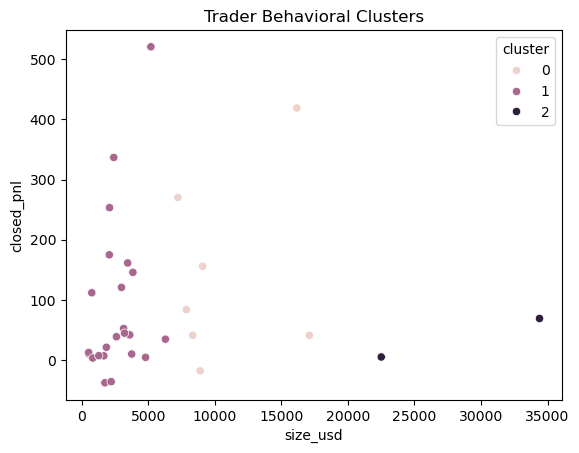

In [125]:
plt.figure()
sns.scatterplot(
    x='size_usd',
    y='closed_pnl',
    hue='cluster',
    data=trader_summary
)
plt.title("Trader Behavioral Clusters")
plt.show()

Methodology

In [ ]:
1. Data Preparation

Two datasets were used:
Bitcoin Market Sentiment (Fear/Greed classification by date)
Historical Hyperliquid Trader Data (trade-level execution details)

The following preprocessing steps were performed:
Cleaned column names and standardized formatting
Converted timestamp fields to datetime format
Extracted daily date from intraday timestamps
Aligned and merged trader data with sentiment data on daily level
Removed duplicates and handled missing values

Created derived features such as:
Daily trader PnL
Win indicator (1 = profitable trade, 0 = loss)
Trade frequency segment (Frequent vs Infrequent)
Average trade size (USD)

The merged dataset enabled analysis of trader performance conditional on market sentiment regimes.

2. Feature Engineering & Segmentation

To analyze behavioral differences, traders were segmented based on activity level:
1.Frequent traders: Accounts with trade counts above median
2.Infrequent traders: Accounts below median trade count
Additional behavioral metrics included:
1.Average trade size
2.Win rate
3.Mean daily PnL

This segmentation allowed comparison of performance across different sentiment environments.

3. Sentiment-Based Performance Analysis

Performance metrics were evaluated across five sentiment regimes:
1.Extreme Fear
2.Fear
3.Neutral
4.Greed
5.Extreme Greed

For each regime, the following were analyzed:
1.Average PnL
2.Win rate
3.Performance by frequency segment
4.Trade distribution patterns

This enabled identification of behavioral shifts under different psychological market conditions.

4.Validation of Findings

To ensure robustness:
1.Sample sizes for each sentiment-segment combination were analyzed
2.Large trade counts (thousands of observations) confirmed statistical reliability
3.Performance dispersion across regimes was examined to identify structural patterns rather than random fluctuations